# **Preparación de los datos**

## Extracción

In [21]:
import pandas as pd
import numpy as np
data = pd.read_csv('TelecomX_data.csv')
data.head()

,customerid,churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,...,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges_monthly,account_charges_total,daily_accounts
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


## Correlación de variables numéricas

In [22]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerid                 7043 non-null   str    
 1   churn                      7043 non-null   str    
 2   customer_gender            7043 non-null   str    
 3   customer_seniorcitizen     7043 non-null   int64  
 4   customer_partner           7043 non-null   str    
 5   customer_dependents        7043 non-null   str    
 6   customer_tenure            7043 non-null   int64  
 7   phone_phoneservice         7043 non-null   str    
 8   phone_multiplelines        7043 non-null   str    
 9   internet_internetservice   7043 non-null   str    
 10  internet_onlinesecurity    7043 non-null   str    
 11  internet_onlinebackup      7043 non-null   str    
 12  internet_deviceprotection  7043 non-null   str    
 13  internet_techsupport       7043 non-null   str    
 14  int

In [23]:
variables_numericas = data.select_dtypes( include = ['int64', 'float64'])
matriz_corr = variables_numericas.corr()
matriz_corr

,customer_seniorcitizen,customer_tenure,account_charges_monthly,account_charges_total,daily_accounts
customer_seniorcitizen,1.000000,0.016567,0.220173,0.103006,0.220173
customer_tenure,0.016567,1.000000,0.247900,0.826178,0.247900
account_charges_monthly,0.220173,0.247900,1.000000,0.651174,1.000000
account_charges_total,0.103006,0.826178,0.651174,1.000000,0.651174
daily_accounts,0.220173,0.247900,1.000000,0.651174,1.000000


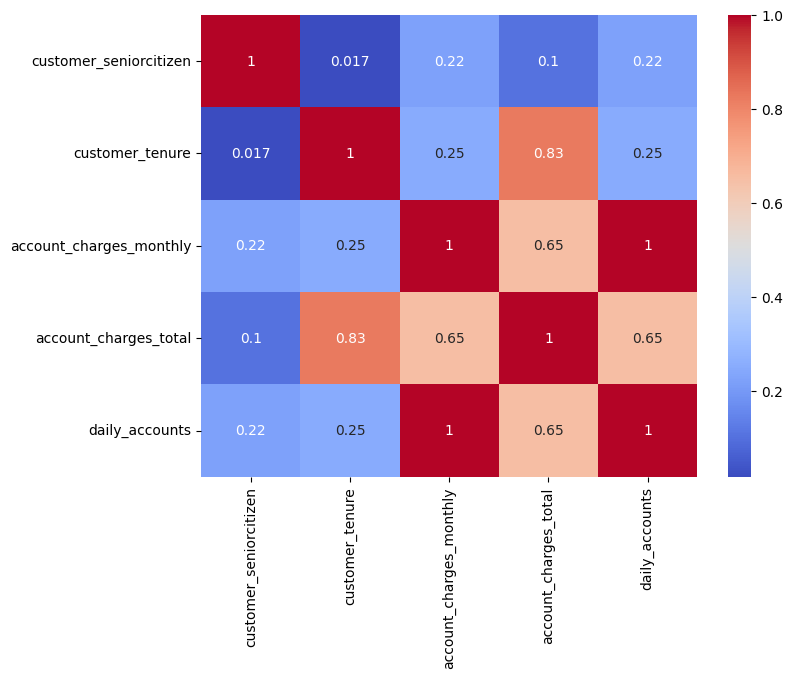

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(
    variables_numericas.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()

## Correlación de variables categóricas

In [25]:
data.columns

Index(['customerid', 'churn', 'customer_gender', 'customer_seniorcitizen',
       'customer_partner', 'customer_dependents', 'customer_tenure',
       'phone_phoneservice', 'phone_multiplelines', 'internet_internetservice',
       'internet_onlinesecurity', 'internet_onlinebackup',
       'internet_deviceprotection', 'internet_techsupport',
       'internet_streamingtv', 'internet_streamingmovies', 'account_contract',
       'account_paperlessbilling', 'account_paymentmethod',
       'account_charges_monthly', 'account_charges_total', 'daily_accounts'],
      dtype='str')

In [26]:
variables_categoricas = data.select_dtypes(include=['object']).columns
variables_categoricas = variables_categoricas.drop('churn')

#Tabla de proporción por categoria
for col in variables_categoricas:
    print(f'\n🔍 Analisis de variable: {col}')
    display(pd.crosstab(data[col], data['churn'], normalize = 'index') * 100)


🔍 Analisis de variable: customerid


C:\Users\andre\AppData\Local\Temp\ipykernel_19648\1159389914.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  variables_categoricas = data.select_dtypes(include=['object']).columns


churn,No,Yes
customerid,,
0002-ORFBO,100.0,0.0
0003-MKNFE,100.0,0.0
0004-TLHLJ,0.0,100.0
0011-IGKFF,0.0,100.0
0013-EXCHZ,0.0,100.0
...,...,...
9987-LUTYD,100.0,0.0
9992-RRAMN,0.0,100.0
9992-UJOEL,100.0,0.0



🔍 Analisis de variable: customer_gender


churn,No,Yes
customer_gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


...

churn,No,Yes
account_contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858



🔍 Analisis de variable: account_paperlessbilling


churn,No,Yes
account_paperlessbilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092



🔍 Analisis de variable: account_paymentmethod


churn,No,Yes
account_paymentmethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


## Eliminación de columnas irrelevantes

Se elimina la variable daily_accounts debido a su correlación perfecta (r=1.0) con account_charges_monthly, evitando redundancia y multicolinealidad en el modelo. También se elimina customerid puesto que sólo es un identificador del cliente. De igual manera, account_charges_total debido a su correlación (0.65) con account_charges_monthly pues se piensa trabajar regresión lineal.

In [27]:
# Elimina las columnas 'customerid', 'daily_accounts', account_charges_total'
data.drop(columns = ['customerid', 'daily_accounts', 'account_charges_total'], inplace = True)

## Encoding

In [28]:
# Separa variables
X = data.drop('churn', axis = 1)
y = data['churn']

In [29]:
X

,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,internet_onlinesecurity,internet_onlinebackup,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges_monthly
0,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60
1,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90
2,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90
3,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00
4,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Female,0,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15
7039,Male,0,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10
7040,Male,0,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30
7041,Male,0,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85


In [30]:
y

0        No
1        No
2       Yes
3       Yes
4       Yes
       ... 
7038     No
7039    Yes
7040     No
7041     No
7042     No
Name: churn, Length: 7043, dtype: str

In [31]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y,  random_state = 5)

### Transformando las variables categóricas

In [32]:
import sklearn 
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [34]:
variables_categoricas = ['customer_gender', 'customer_seniorcitizen',
       'customer_partner', 'customer_dependents',
       'phone_phoneservice', 'phone_multiplelines', 'internet_internetservice',
       'internet_onlinesecurity', 'internet_onlinebackup',
       'internet_deviceprotection', 'internet_techsupport',
       'internet_streamingtv', 'internet_streamingmovies', 'account_contract',
       'account_paperlessbilling', 'account_paymentmethod',
       ]

In [35]:
one_hot = make_column_transformer((
    OneHotEncoder(drop = 'if_binary'),
    (variables_categoricas)
),
    remainder = 'passthrough',
    sparse_threshold=0,
    force_int_remainder_cols=False)

X_test_encoded = one_hot.fit_transform(X_train)

column_names = one_hot.get_feature_names_out()
X_test_encoded = pd.DataFrame(X_test_encoded, columns=column_names)
X_test_encoded.head()

c:\Users\andre\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\compose\_column_transformer.py:978: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(


,onehotencoder__customer_gender_Male,onehotencoder__customer_seniorcitizen_1,onehotencoder__customer_partner_Yes,onehotencoder__customer_dependents_Yes,onehotencoder__phone_phoneservice_Yes,onehotencoder__phone_multiplelines_No,onehotencoder__phone_multiplelines_No phone service,onehotencoder__phone_multiplelines_Yes,onehotencoder__internet_internetservice_DSL,onehotencoder__internet_internetservice_Fiber optic,...,onehotencoder__account_contract_Month-to-month,onehotencoder__account_contract_One year,onehotencoder__account_contract_Two year,onehotencoder__account_paperlessbilling_Yes,onehotencoder__account_paymentmethod_Bank transfer (automatic),onehotencoder__account_paymentmethod_Credit card (automatic),onehotencoder__account_paymentmethod_Electronic check,onehotencoder__account_paymentmethod_Mailed check,remainder__customer_tenure,remainder__account_charges_monthly
0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,61.0,61.45
1,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,69.0,61.45
2,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,47.0,84.95
3,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,71.0,109.00
4,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,12.0,43.80


### Tranformando la variable respuesta

In [36]:
from sklearn.preprocessing import LabelEncoder

In [37]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_train)
y

array([0, 0, 0, ..., 0, 0, 0], shape=(5282,))

## Verificación de la Proporción de Cancelación (Churn)

In [38]:
data['churn'].value_counts(normalize = True).round(2)

churn
No     0.73
Yes    0.27
Name: proportion, dtype: float64

## Desbalanceo de clases

In [39]:
pd.Series(y_train).value_counts(normalize=True)

churn
No     0.73457
Yes    0.26543
Name: proportion, dtype: float64

In [40]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_test_encoded, y_train)

## Normalización o estandarización 

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train_res)

X_train_scaled = scaler.transform(X_train_res)
X_test_scaled = scaler.transform(X_test_encoded)

# **Correlación y selección de variables**

## Análisis de correlación

In [42]:
# La matriz de las variables numéricas se hizo anteriormente

In [45]:
variables_categoricas_corr= X_test_encoded.corr()
variables_categoricas_corr.head()

,onehotencoder__customer_gender_Male,onehotencoder__customer_seniorcitizen_1,onehotencoder__customer_partner_Yes,onehotencoder__customer_dependents_Yes,onehotencoder__phone_phoneservice_Yes,onehotencoder__phone_multiplelines_No,onehotencoder__phone_multiplelines_No phone service,onehotencoder__phone_multiplelines_Yes,onehotencoder__internet_internetservice_DSL,onehotencoder__internet_internetservice_Fiber optic,...,onehotencoder__account_contract_Month-to-month,onehotencoder__account_contract_One year,onehotencoder__account_contract_Two year,onehotencoder__account_paperlessbilling_Yes,onehotencoder__account_paymentmethod_Bank transfer (automatic),onehotencoder__account_paymentmethod_Credit card (automatic),onehotencoder__account_paymentmethod_Electronic check,onehotencoder__account_paymentmethod_Mailed check,remainder__customer_tenure,remainder__account_charges_monthly
onehotencoder__customer_gender_Male,1.000000,-0.005450,0.001716,0.008462,0.008294,0.014229,-0.008294,-0.009446,0.009400,-0.012948,...,-0.009905,0.016946,-0.004525,-0.005985,0.001438,0.001066,-0.010099,0.008929,0.012311,-0.011731
onehotencoder__customer_seniorcitizen_1,-0.005450,1.000000,0.013932,-0.203720,0.005281,-0.134491,-0.005281,0.139003,-0.107375,0.254081,...,0.138385,-0.055742,-0.108442,0.159719,-0.024798,-0.019790,0.165540,-0.142852,0.010540,0.217920
onehotencoder__customer_partner_Yes,0.001716,0.013932,1.000000,0.443237,0.004274,-0.130032,-0.004274,0.133900,0.003266,-0.004771,...,-0.289656,0.099882,0.242906,-0.020289,0.126363,0.078410,-0.096972,-0.093038,0.384483,0.089030
onehotencoder__customer_dependents_Yes,0.008462,-0.203720,0.443237,1.000000,-0.000336,0.027150,0.000336,-0.027628,0.050419,-0.164566,...,-0.231859,0.084732,0.189905,-0.097200,0.048009,0.063121,-0.148770,0.058166,0.162659,-0.114632
onehotencoder__phone_phoneservice_Yes,0.008294,0.005281,0.004274,-0.000336,1.000000,0.311171,-1.000000,0.279781,-0.452483,0.290321,...,0.006429,-0.013198,0.005022,0.011535,0.001511,-0.005104,-0.003591,0.007595,-0.008183,0.243439


# **Análisis dirigido**

## Tiempo de contrato vs Churn

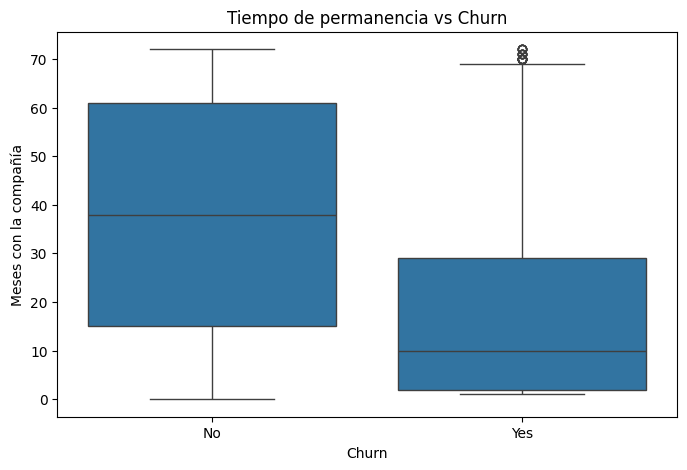

In [47]:
plt.figure(figsize=(8,5))
sns.boxplot(x='churn', y='customer_tenure', data=data)

plt.title('Tiempo de permanencia vs Churn')
plt.xlabel('Churn')
plt.ylabel('Meses con la compañía')

plt.show()

## Gasto mensual vs Churn

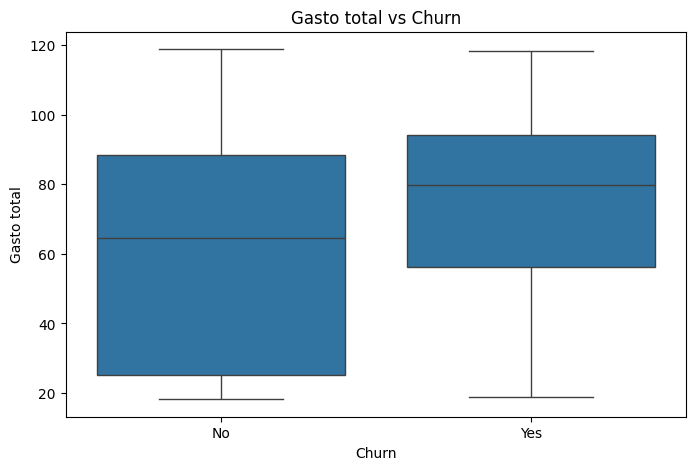

In [49]:
plt.figure(figsize=(8,5))
sns.boxplot(x='churn', y='account_charges_monthly', data=data)

plt.title('Gasto total vs Churn')
plt.xlabel('Churn')
plt.ylabel('Gasto total')

plt.show()

## Soporte técnico VS Churn

In [51]:
data.columns

Index(['churn', 'customer_gender', 'customer_seniorcitizen',
       'customer_partner', 'customer_dependents', 'customer_tenure',
       'phone_phoneservice', 'phone_multiplelines', 'internet_internetservice',
       'internet_onlinesecurity', 'internet_onlinebackup',
       'internet_deviceprotection', 'internet_techsupport',
       'internet_streamingtv', 'internet_streamingmovies', 'account_contract',
       'account_paperlessbilling', 'account_paymentmethod',
       'account_charges_monthly'],
      dtype='str')

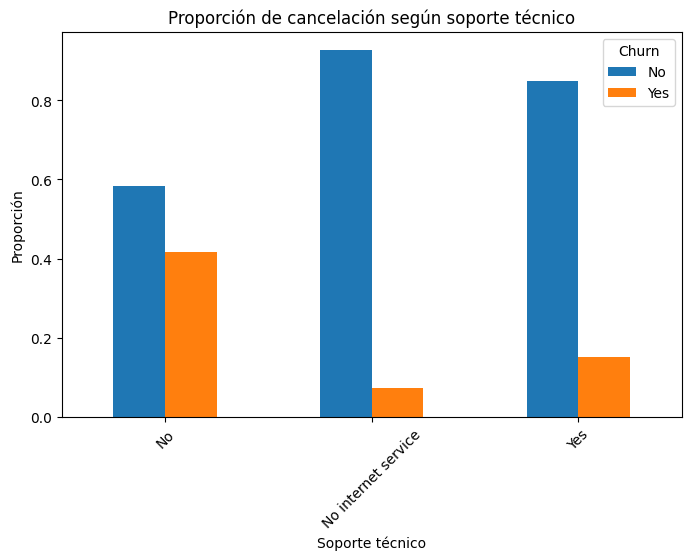

In [ ]:
tabla_soporte_vs_churn = pd.crosstab(data['internet_techsupport'], data['churn'], normalize='index')

tabla_soporte_vs_churn.plot(kind='bar', figsize=(8,5))

plt.title('Proporción de cancelación según soporte técnico')
plt.xlabel('Soporte técnico')
plt.ylabel('Proporción')
plt.xticks(rotation=45)

plt.legend(title='Churn')

plt.show()

## Tipo de contrato VS Churn

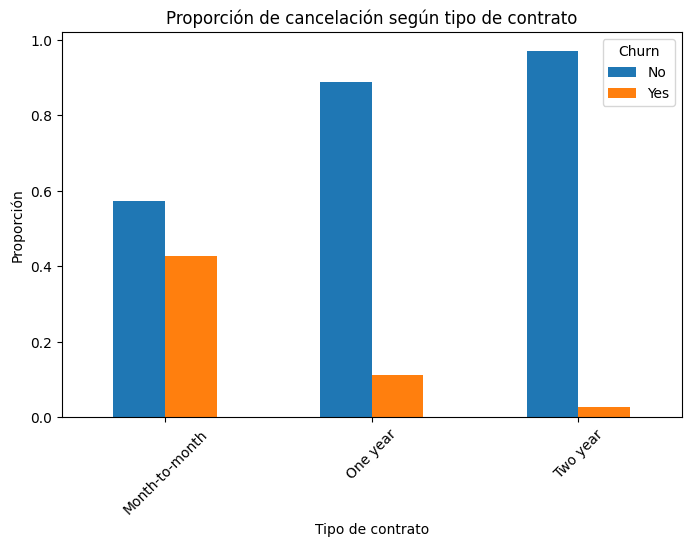

In [59]:
tabla_soporte_vs_churn = pd.crosstab(data['account_contract'], data['churn'], normalize='index')

tabla_soporte_vs_churn.plot(kind='bar', figsize=(8,5))

plt.title('Proporción de cancelación según tipo de contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Proporción')
plt.xticks(rotation=45)

plt.legend(title='Churn')

plt.show()